In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('European_Bank.csv')

In [3]:
df.shape

(10000, 14)

In [4]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [9]:
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [10]:
df['HasCrCard'].unique()
df['IsActiveMember'].unique()
df['Exited'].unique()
df['CreditScore'].describe()
df['CustomerId'].nunique() == len(df)

True

In [11]:
df['Exited'].value_counts(normalize = True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [12]:
df['Year'].unique()

array([2025])

In [13]:
df = df.drop(columns = ['Year','Surname'])

In [14]:
df['AgeGroup'] = pd.cut(df['Age'] , bins = [0,30,45,60,100], labels = ['<30','30-45','46-60','60+'])

In [15]:
df['AgeGroup']

0       30-45
1       30-45
2       30-45
3       30-45
4       30-45
        ...  
9995    30-45
9996    30-45
9997    30-45
9998    30-45
9999      <30
Name: AgeGroup, Length: 10000, dtype: category
Categories (4, str): ['<30' < '30-45' < '46-60' < '60+']

In [16]:
# df['AgeGroup'].describe()
# df['AgeGroup'].value_counts()
df['AgeGroup'].info()

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: AgeGroup
Non-Null Count  Dtype   
--------------  -----   
10000 non-null  category
dtypes: category(1)
memory usage: 10.1 KB


In [17]:
df['CreditBand'] = pd.cut(df['CreditScore'],bins = [0,580,700,850], labels = ['Low','Medium','High'])

In [18]:
df['CreditBand']
df['CreditBand'].describe()
df['CreditBand'].value_counts()
df['CreditBand'].info()

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: CreditBand
Non-Null Count  Dtype   
--------------  -----   
10000 non-null  category
dtypes: category(1)
memory usage: 10.0 KB


In [19]:
df['TenureGroup'] = pd.cut(df['Tenure'],bins = [-1,2,5,10], labels = ['New','Med-Term','Long-Term'])

In [20]:
df['TenureGroup']
# df['TenureGroup'].describe()
df['TenureGroup'].value_counts()
# df['TenureGroup'].info()

TenureGroup
Long-Term    4494
Med-Term     3010
New          2496
Name: count, dtype: int64

In [21]:
# df['BalanceSegment'] = pd.cut(df['Balance'],bins = [-1,0,100000,250899], labels = ['Zero-Balance','Low-balance','High-balance'])
def balanceSegmentation(x):
    if x == 0:
        return 'Zero-Balance'
    elif x < 100000:
        return 'Low-Balance'
    else:
        return 'High-Balance'
df['BalanceSegment'] = df['Balance'].apply(balanceSegmentation)

In [22]:
df[['Balance','BalanceSegment']]

,Balance,BalanceSegment
0,0.00,Zero-Balance
1,83807.86,Low-Balance
2,159660.80,High-Balance
3,0.00,Zero-Balance
4,125510.82,High-Balance
...,...,...
9995,0.00,Zero-Balance
9996,57369.61,Low-Balance
9997,0.00,Zero-Balance
9998,75075.31,Low-Balance


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CustomerId       10000 non-null  int64   
 1   CreditScore      10000 non-null  int64   
 2   Geography        10000 non-null  str     
 3   Gender           10000 non-null  str     
 4   Age              10000 non-null  int64   
 5   Tenure           10000 non-null  int64   
 6   Balance          10000 non-null  float64 
 7   NumOfProducts    10000 non-null  int64   
 8   HasCrCard        10000 non-null  int64   
 9   IsActiveMember   10000 non-null  int64   
 10  EstimatedSalary  10000 non-null  float64 
 11  Exited           10000 non-null  int64   
 12  AgeGroup         10000 non-null  category
 13  CreditBand       10000 non-null  category
 14  TenureGroup      10000 non-null  category
 15  BalanceSegment   10000 non-null  str     
dtypes: category(3), float64(2), int64(8), str(3)
memory 

In [24]:
df[['AgeGroup','TenureGroup','BalanceSegment','CreditBand']].apply(lambda x : x.value_counts())

,AgeGroup,TenureGroup,BalanceSegment,CreditBand
30-45,5921.0,NaN,NaN,NaN
46-60,1647.0,NaN,NaN,NaN
60+,464.0,NaN,NaN,NaN
<30,1968.0,NaN,NaN,NaN
High,NaN,NaN,NaN,3116.0
High-Balance,NaN,NaN,4799.0,NaN
Long-Term,NaN,4494.0,NaN,NaN
Low,NaN,NaN,NaN,2393.0
Low-Balance,NaN,NaN,1584.0,NaN
Med-Term,NaN,3010.0,NaN,NaN


In [25]:
df.to_csv("Bank_churn_clean.csv",index = False)

In [26]:
overall_churn = df['Exited'].mean()*100
print(f"Overall Churn Rate : {overall_churn:.2f}%")

Overall Churn Rate : 20.37%


In [27]:
def churn_rate_by(col):
    result = df.groupby(col)['Exited'].agg(('mean','count'))
    result['mean'] = (result['mean']*100).round(2)
    result.columns = ['ChurnRate(%)','CustomerCount'] 
    return result.sort_values('ChurnRate(%)',ascending =False)

In [28]:
# churn_rate_by('Geography')
# churn_rate_by('Gender')
churn_rate_by('AgeGroup')
# churn_rate_by('CreditBand')
# churn_rate_by('TenureGroup')
# churn_rate_by('BalanceSegment')
# churn_rate_by('NumOfProducts')
# churn_rate_by('IsActiveMember')
# churn_rate_by('HasCrCard')

,ChurnRate(%),CustomerCount
AgeGroup,,
46-60,51.12,1647
60+,24.78,464
30-45,15.74,5921
<30,7.52,1968


In [29]:
def churn_contribution_by(col):
    churned = df[df['Exited'] == 1]
    contribution = (churned[col].value_counts(normalize =True)*100).round(2)
    return contribution

In [30]:
churn_contribution_by('Geography')
# churn_contribution_by('AgeGroup')
# churn_contribution_by('BalanceSegment')


Geography
Germany    39.96
France     39.76
Spain      20.27
Name: proportion, dtype: float64

In [31]:
df.groupby('Exited')[['CreditScore','Age','Tenure','Balance','EstimatedSalary','NumOfProducts']].mean().round(2)

,CreditScore,Age,Tenure,Balance,EstimatedSalary,NumOfProducts
Exited,,,,,,
0,651.85,37.41,5.03,72745.30,99738.39,1.54
1,645.35,44.84,4.93,91108.54,101465.68,1.48


<Axes: xlabel='AgeGroup', ylabel='Exited'>

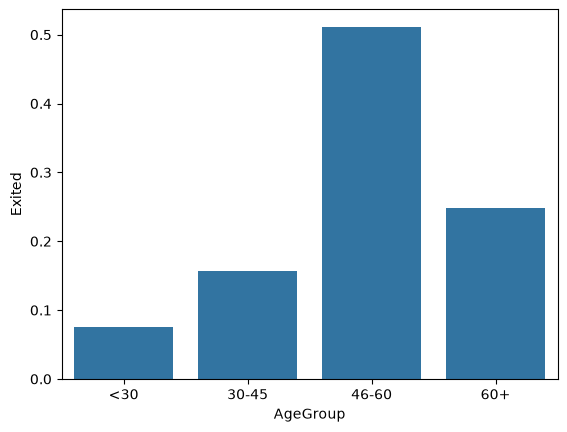

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Overall churn pie/bar
# sns.countplot(data=df, x='Exited')

# Churn rate by geography
# sns.barplot(data=df, x='Geography', y='Exited', errorbar=None)

# Churn rate by age group
sns.barplot(data=df, x='AgeGroup', y='Exited', errorbar=None)

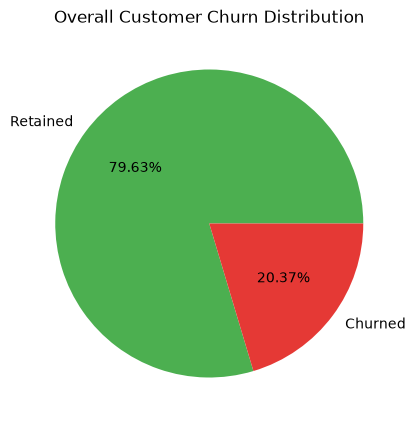

In [33]:
# 1. Overall churn split (pie)
plt.figure(figsize=(5,5))
df['Exited'].value_counts().plot.pie(autopct='%1.2f%%', labels=['Retained','Churned'], colors=['#4CAF50','#E53935'])
plt.title('Overall Customer Churn Distribution')
plt.ylabel('')
plt.show()


In [34]:
# 2. Overall churn count (bar)
# plt.figure(figsize=(5,4))
# sns.countplot(data=df, x='Exited', palette=['#4CAF50','#E53935'])
# plt.xticks([0,1], ['Retained','Churned'])
# plt.title('Churn Count')
# plt.show()

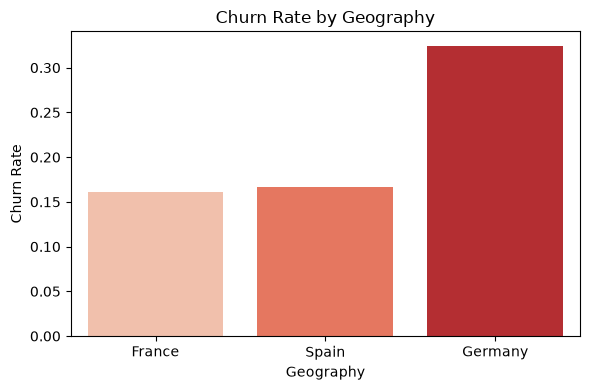

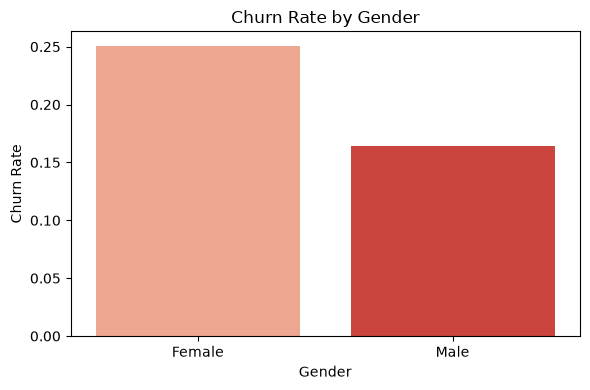

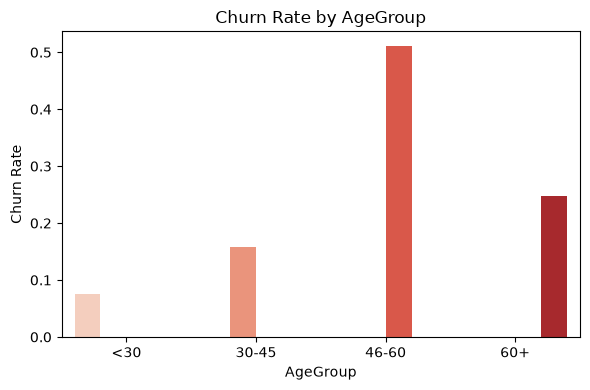

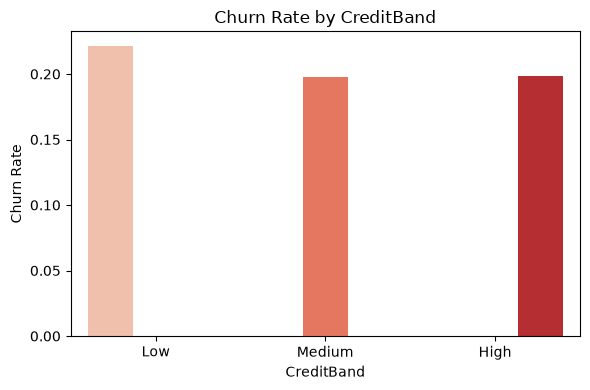

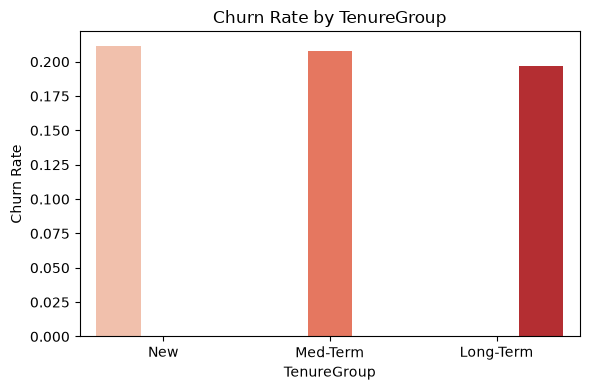

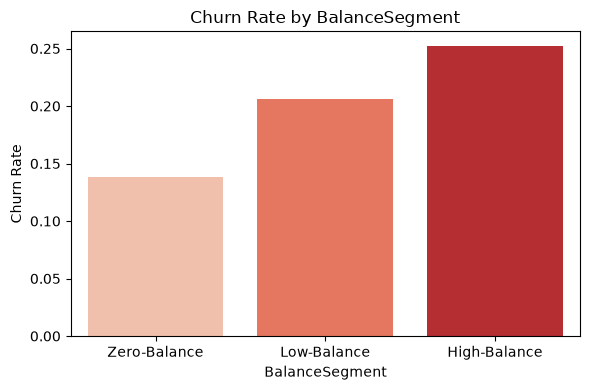

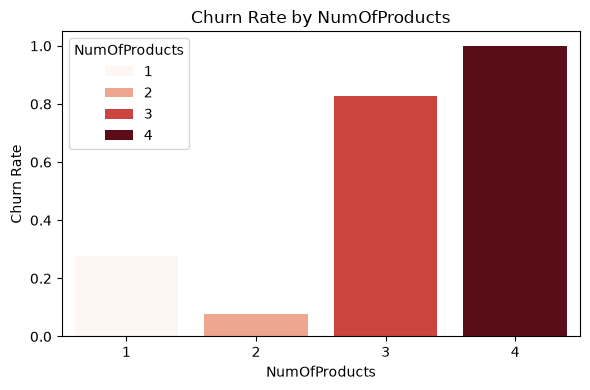

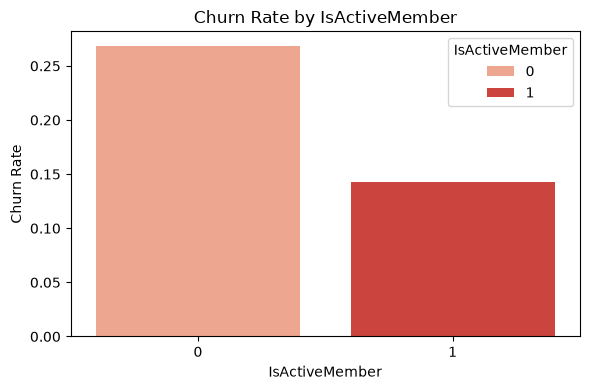

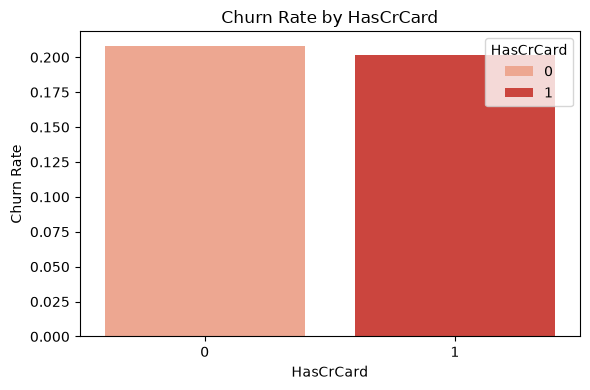

In [35]:
segment_cols = ['Geography','Gender','AgeGroup','CreditBand','TenureGroup',
                 'BalanceSegment','NumOfProducts','IsActiveMember','HasCrCard']

for col in segment_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x=col, y='Exited', errorbar=None,hue=col,palette='Reds')
    plt.ylabel('Churn Rate')
    plt.title(f'Churn Rate by {col}')
    # plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

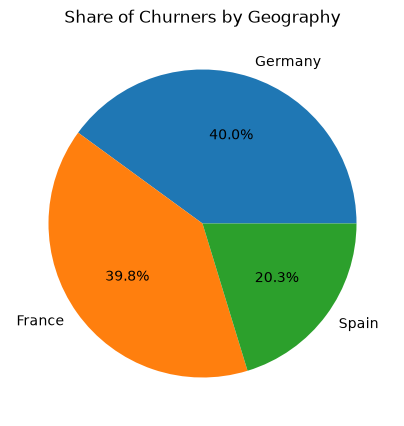

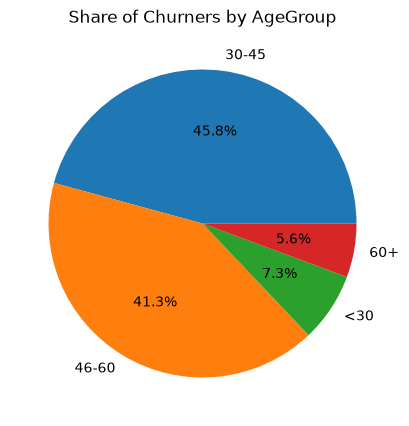

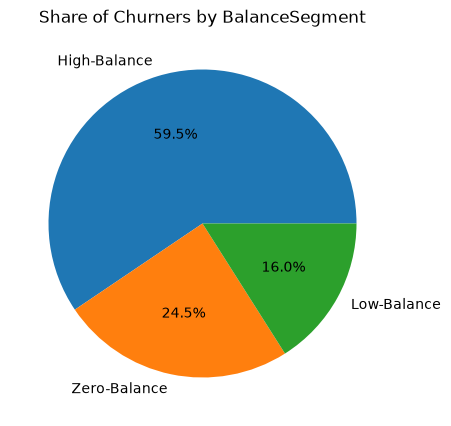

In [36]:
churned = df[df['Exited']==1]

for col in ['Geography','AgeGroup','BalanceSegment']:
    plt.figure(figsize=(5,5))
    churned[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(f'Share of Churners by {col}')
    plt.ylabel('')
    plt.show()

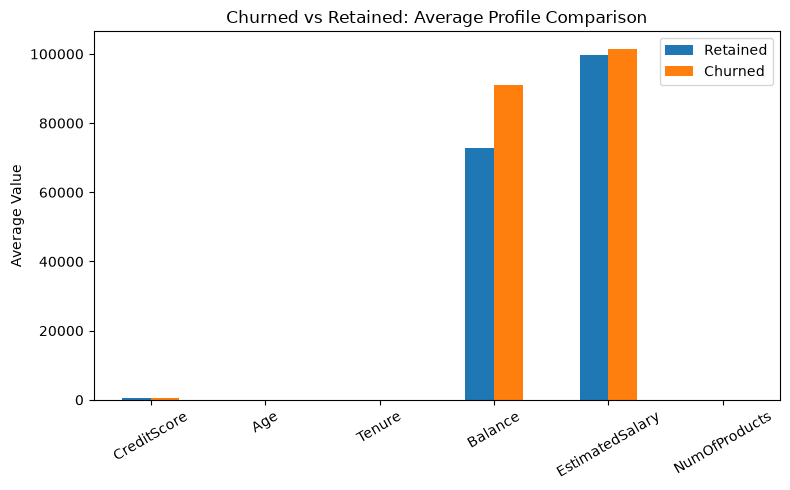

In [37]:
profile = df.groupby('Exited')[['CreditScore','Age','Tenure','Balance','EstimatedSalary','NumOfProducts']].mean()
profile.T.plot(kind='bar', figsize=(8,5))
plt.title('Churned vs Retained: Average Profile Comparison')
plt.ylabel('Average Value')
plt.legend(['Retained','Churned'])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


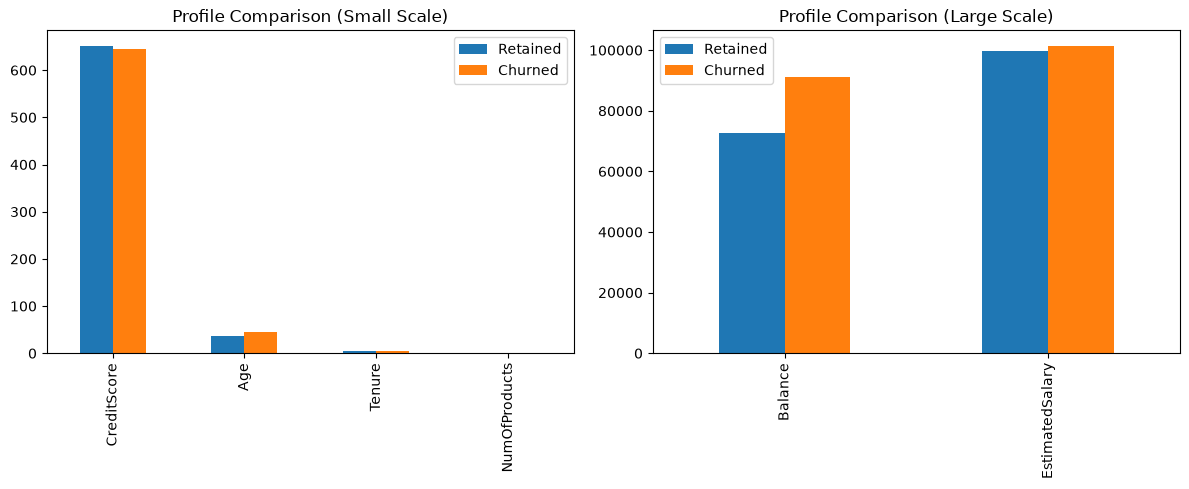

In [38]:
# Split version (recommended)
fig, axes = plt.subplots(1,2, figsize=(12,5))
profile[['CreditScore','Age','Tenure','NumOfProducts']].T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Profile Comparison (Small Scale)')
axes[0].legend(['Retained','Churned'])
profile[['Balance','EstimatedSalary']].T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Profile Comparison (Large Scale)')
axes[1].legend(['Retained','Churned'])
plt.tight_layout()
plt.show()

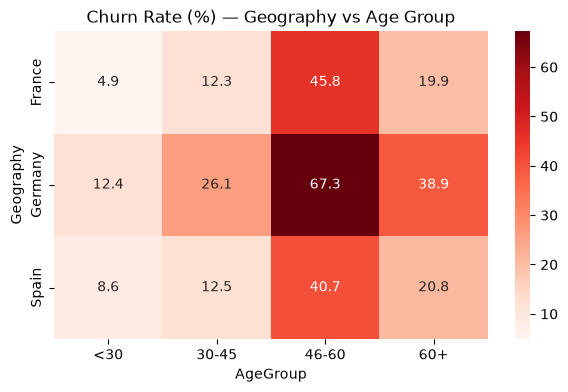

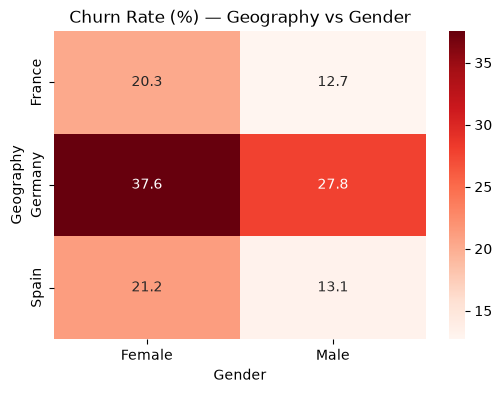

In [39]:
# Geography x AgeGroup churn heatmap
pivot1 = df.pivot_table(index='Geography', columns='AgeGroup', values='Exited', aggfunc='mean')
plt.figure(figsize=(7,4))
sns.heatmap(pivot1*100, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) — Geography vs Age Group')
plt.show()

# Geography x Gender churn heatmap
pivot2 = df.pivot_table(index='Geography', columns='Gender', values='Exited', aggfunc='mean')
plt.figure(figsize=(6,4))
sns.heatmap(pivot2*100, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) — Geography vs Gender')
plt.show()

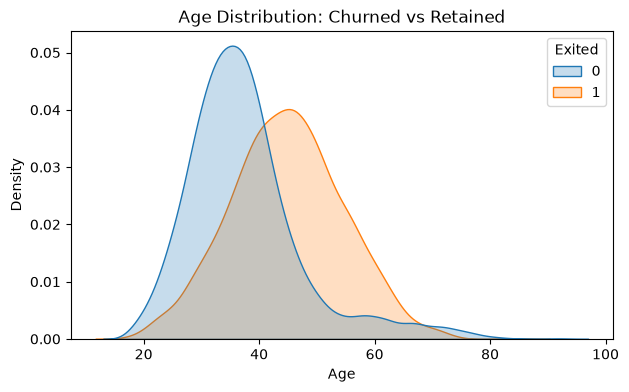

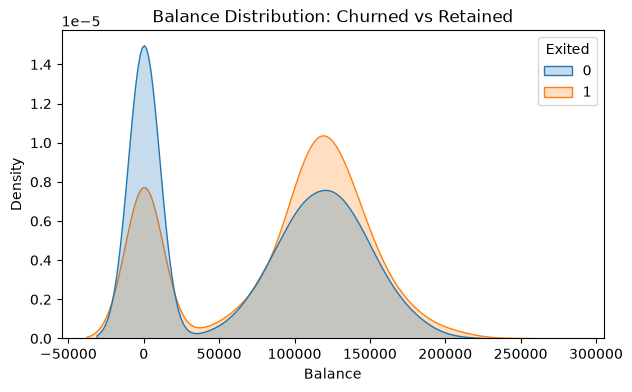

In [40]:
# Age distribution split by churn
plt.figure(figsize=(7,4))
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True, common_norm=False)
plt.title('Age Distribution: Churned vs Retained')
plt.show()

# Balance distribution split by churn
plt.figure(figsize=(7,4))
sns.kdeplot(data=df, x='Balance', hue='Exited', fill=True, common_norm=False)
plt.title('Balance Distribution: Churned vs Retained')
plt.show()

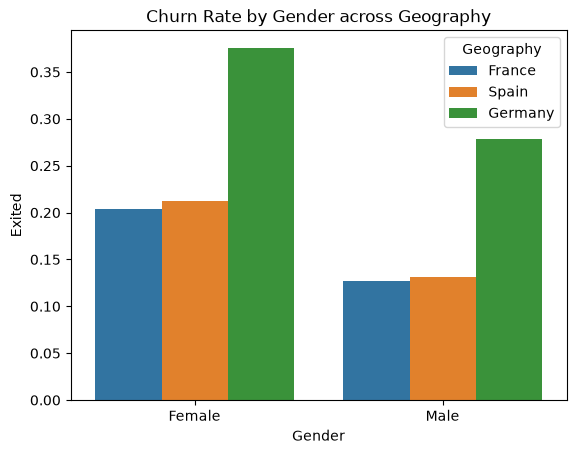

In [41]:
churn_rate_by('Gender')
sns.barplot(data=df, x='Gender', y='Exited', hue='Geography', errorbar=None)
plt.title('Churn Rate by Gender across Geography')
plt.show()

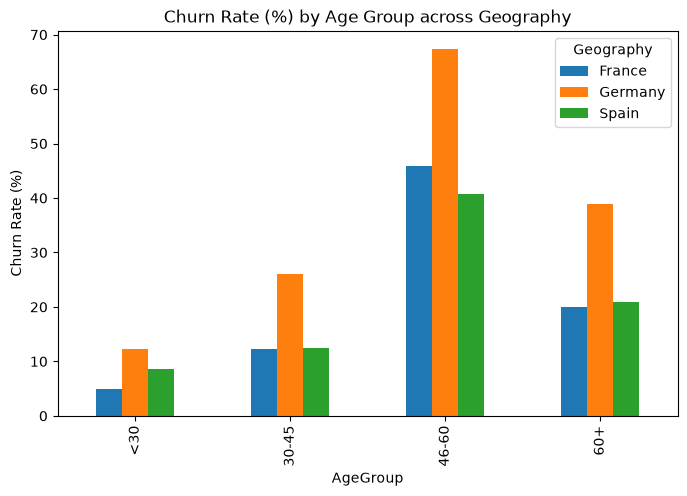

In [42]:
pivot = df.pivot_table(index='AgeGroup', columns='Geography', values='Exited', aggfunc='mean')*100
pivot.plot(kind='bar', figsize=(8,5))
plt.title('Churn Rate (%) by Age Group across Geography')
plt.ylabel('Churn Rate (%)')
plt.show()

In [43]:
df[(df['Geography']=='Germany') & (df['AgeGroup']=='46-60')]['Exited'].mean()

np.float64(0.6733067729083665)

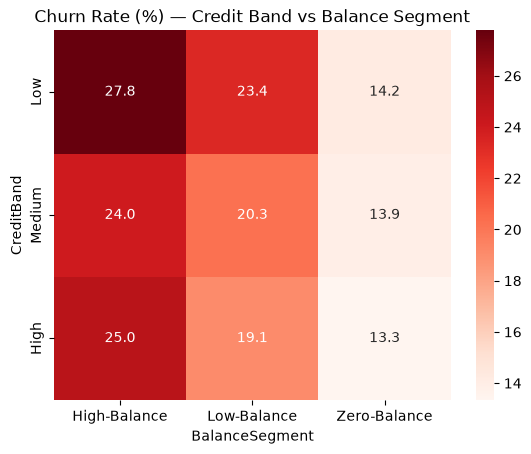

In [44]:
# Does low credit score + high balance combine to increase risk?
pivot2 = df.pivot_table(index='CreditBand', columns='BalanceSegment', values='Exited', aggfunc='mean')*100
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) — Credit Band vs Balance Segment')
plt.show()

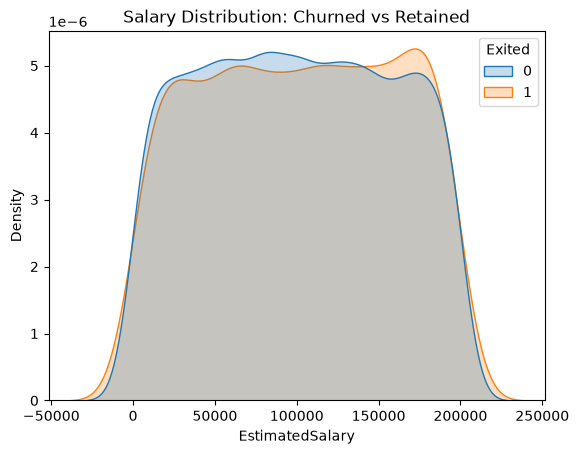

In [45]:
# Salary vs churn (does salary alone matter, independent of balance?)
sns.kdeplot(data=df, x='EstimatedSalary', hue='Exited', fill=True, common_norm=False)
plt.title('Salary Distribution: Churned vs Retained')
plt.show()

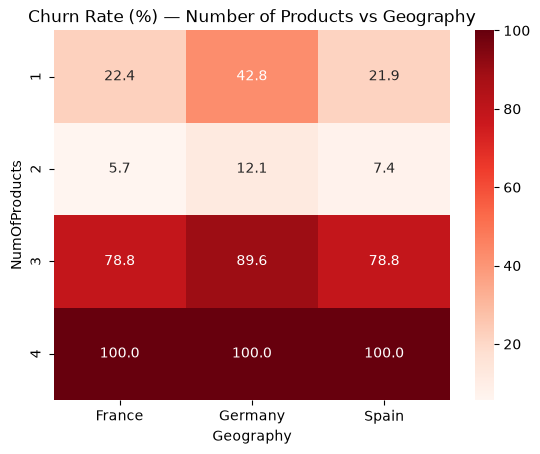

In [46]:
pivot3 = df.pivot_table(index='NumOfProducts', columns='Geography', values='Exited', aggfunc='mean')*100
sns.heatmap(pivot3, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) — Number of Products vs Geography')
plt.show()

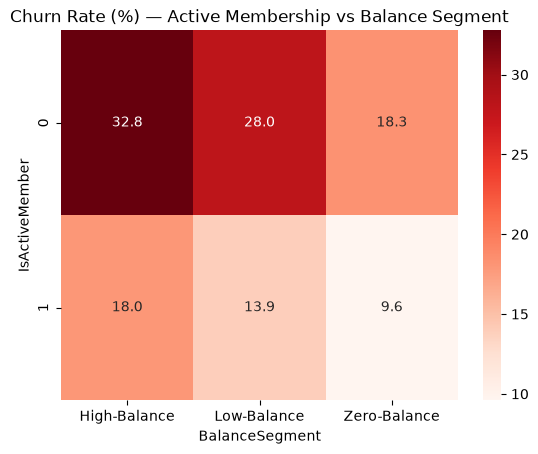

In [47]:
pivot4 = df.pivot_table(index='IsActiveMember', columns='BalanceSegment', values='Exited', aggfunc='mean')*100
sns.heatmap(pivot4, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) — Active Membership vs Balance Segment')
plt.show()

In [48]:
df.pivot_table(index='Geography', columns='Gender', values='Exited', aggfunc='mean')*100

Gender,Female,Male
Geography,,
France,20.344980,12.713404
Germany,37.552389,27.811550
Spain,21.212121,13.112392


In [49]:
df['HighValue'] = ((df['BalanceSegment']=='High-Balance') | (df['EstimatedSalary'] > df['EstimatedSalary'].quantile(0.75))).astype(int)

In [50]:
df['HighValue']

0       0
1       0
2       1
3       0
4       1
       ..
9995    0
9996    0
9997    0
9998    0
9999    1
Name: HighValue, Length: 10000, dtype: int64

In [51]:
hv_churn = df[df['HighValue']==1]['Exited'].mean()*100
non_hv_churn = df[df['HighValue']==0]['Exited'].mean()*100
print(f"High-Value Churn Rate: {hv_churn:.2f}%")
print(f"Non-High-Value Churn Rate: {non_hv_churn:.2f}%")

High-Value Churn Rate: 23.57%
Non-High-Value Churn Rate: 15.39%


In [52]:
revenue_at_risk = df[(df['HighValue']==1) & (df['Exited']==1)]['Balance'].sum()
total_hv_balance = df[df['HighValue']==1]['Balance'].sum()
pct_at_risk = revenue_at_risk / total_hv_balance * 100

print(f"Total balance held by churned high-value customers: €{revenue_at_risk:,.2f}")
print(f"This represents {pct_at_risk:.2f}% of all high-value customer balances")

Total balance held by churned high-value customers: €166,675,813.87
This represents 24.98% of all high-value customer balances


BalanceSegment  High-Balance  Low-Balance  Zero-Balance
SalaryBand                                             
Low                26.649906    16.666667     13.121434
Medium             23.251418    22.324723     14.036545
High               25.786552    22.623574     14.333895


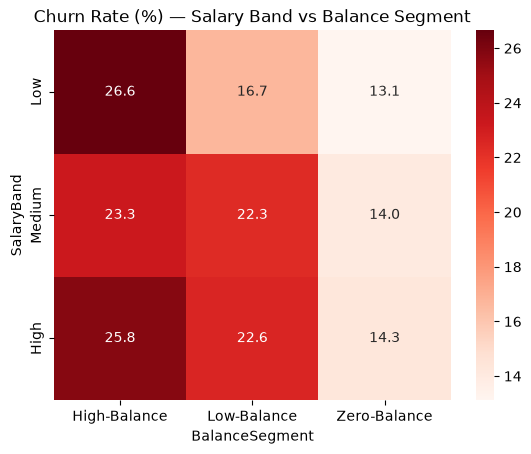

In [56]:
df['SalaryBand'] = pd.qcut(df['EstimatedSalary'], q=3, labels=['Low','Medium','High'])
pivot5 = df.pivot_table(index='SalaryBand', columns='BalanceSegment', values='Exited', aggfunc='mean')*100
print(pivot5)
sns.heatmap(pivot5, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) — Salary Band vs Balance Segment')
plt.show()

In [60]:
hv_churned = df[(df['HighValue']==1) & (df['Exited']==1)]
print(hv_churned['Geography'].value_counts(normalize=True)*100)
print(hv_churned['AgeGroup'].value_counts(normalize=True)*100)

Geography
Germany    51.115760
France     33.054393
Spain      15.829847
Name: proportion, dtype: float64
AgeGroup
30-45    45.676430
46-60    40.794979
<30       8.019526
60+       5.509066
Name: proportion, dtype: float64


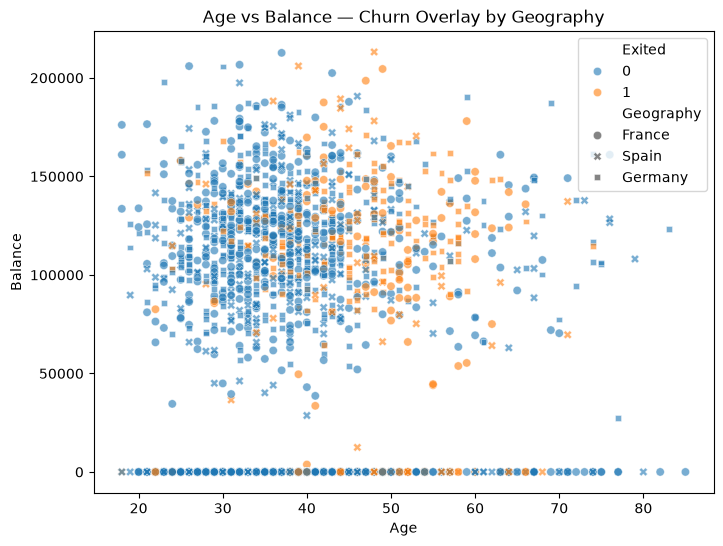

In [55]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df.sample(2000), x='Age', y='Balance', hue='Exited', style='Geography', alpha=0.6)
plt.title('Age vs Balance — Churn Overlay by Geography')
plt.show()